In [1]:
## Import libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Path("charts").mkdir(exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
## Add column names and load the CSV

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv(
    "adult-all-1.csv",
    names=columns,
    header=None,
    skipinitialspace=True
)

print("Original dataset size:", df.shape)
df.head()

Original dataset size: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [12]:
# Remove extra spaces and periods
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip().str.rstrip(".")

print("Missing values before cleaning:")
print((df == "?").sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Replace question marks with missing values
df = df.replace("?", np.nan)

# Remove missing and duplicate rows
df = df.dropna()
df = df.drop_duplicates()

print("\nCleaned dataset size:", df.shape)

Missing values before cleaning:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Duplicate rows: 52

Cleaned dataset size: (45175, 15)


In [20]:
## Explore the data

print("Numerical summary:")
display(df.describe().round(2))

print("Income counts:")
display(df["income"].value_counts())

print("Education counts:")
display(df["education"].value_counts())

print("Occupation counts:")
display(df["occupation"].value_counts())

Numerical summary:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45175.00,45175.00,45175.00,45175.00,45175.00,45175.00
mean,38.56,189738.80,10.12,1102.58,88.69,40.94
std,13.22,105652.44,2.55,7510.25,405.16,12.01
min,17.00,13492.00,1.00,0.00,0.00,1.00
25%,28.00,117392.50,9.00,0.00,0.00,40.00
50%,37.00,178312.00,10.00,0.00,0.00,40.00
75%,47.00,237903.00,13.00,0.00,0.00,45.00
max,90.00,1490400.00,16.00,99999.00,4356.00,99.00


Income counts:


income
<=50K    33973
>50K     11202
Name: count, dtype: int64

Education counts:


education
HS-grad         14770
Some-college     9887
Bachelors        7559
Masters          2513
Assoc-voc        1958
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           822
Prof-school       785
9th               676
12th              575
Doctorate         544
5th-6th           447
1st-4th           220
Preschool          70
Name: count, dtype: int64

Occupation counts:


occupation
Craft-repair         6010
Prof-specialty       6001
Exec-managerial      5980
Adm-clerical         5535
Sales                5405
Other-service        4805
Machine-op-inspct    2965
Transport-moving     2316
Handlers-cleaners    2045
Farming-fishing      1475
Tech-support         1419
Protective-serv       975
Priv-house-serv       230
Armed-Forces           14
Name: count, dtype: int64

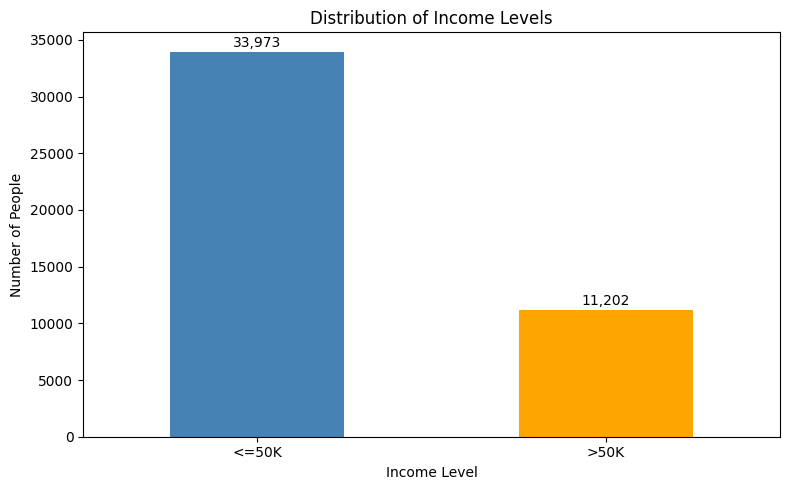

In [ ]:
## Income distribution

income_order = ["<=50K", ">50K"]

income_counts = (
    df["income"]
    .value_counts()
    .reindex(income_order)
)

ax = income_counts.plot(
    kind="bar",
    color=["steelblue", "orange"],
    figsize=(8, 5)
)

plt.title("Distribution of Income Levels")
plt.xlabel("Income Level")
plt.ylabel("Number of People")
plt.xticks(rotation=0)

for position, value in enumerate(income_counts):
    ax.text(
        position,
        value + 400,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "charts/01_income_distribution.png",
    dpi=200
)
plt.show()

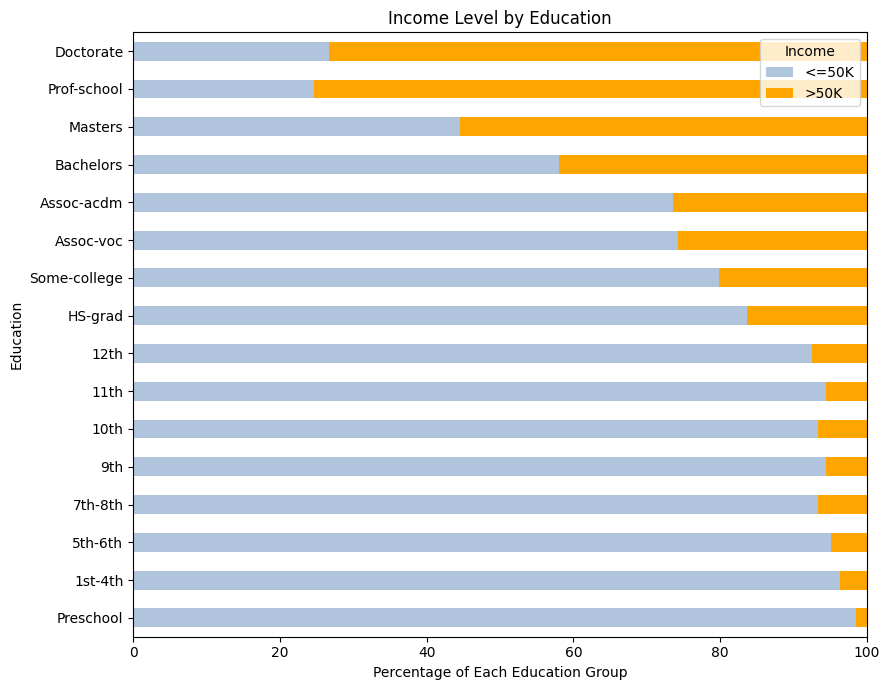

In [ ]:
## Education and income


education_order = (
    df.groupby("education")["education-num"]
    .median()
    .sort_values()
    .index
)

education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

education_income = education_income.reindex(
    education_order
)[income_order]

education_income.plot(
    kind="barh",
    stacked=True,
    color=["lightsteelblue", "orange"],
    figsize=(9, 7)
)

plt.title("Income Level by Education")
plt.xlabel("Percentage of Each Education Group")
plt.ylabel("Education")
plt.xlim(0, 100)
plt.legend(title="Income")
plt.tight_layout()

plt.savefig(
    "charts/02_education_income.png",
    dpi=200
)
plt.show()

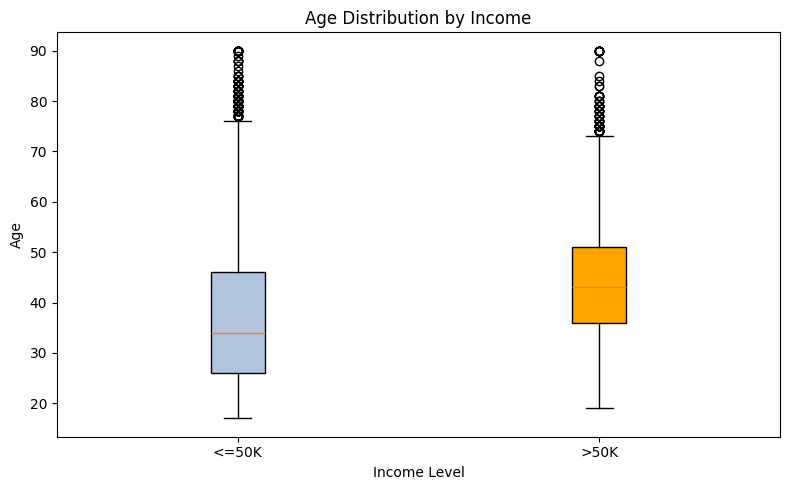

In [ ]:
## Age and income

age_groups = [
    df.loc[df["income"] == "<=50K", "age"],
    df.loc[df["income"] == ">50K", "age"]
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    age_groups,
    tick_labels=["<=50K", ">50K"],
    patch_artist=True
)

box["boxes"][0].set_facecolor("lightsteelblue")
box["boxes"][1].set_facecolor("orange")

plt.title("Age Distribution by Income")
plt.xlabel("Income Level")
plt.ylabel("Age")
plt.tight_layout()

plt.savefig(
    "charts/03_age_income.png",
    dpi=200
)
plt.show()

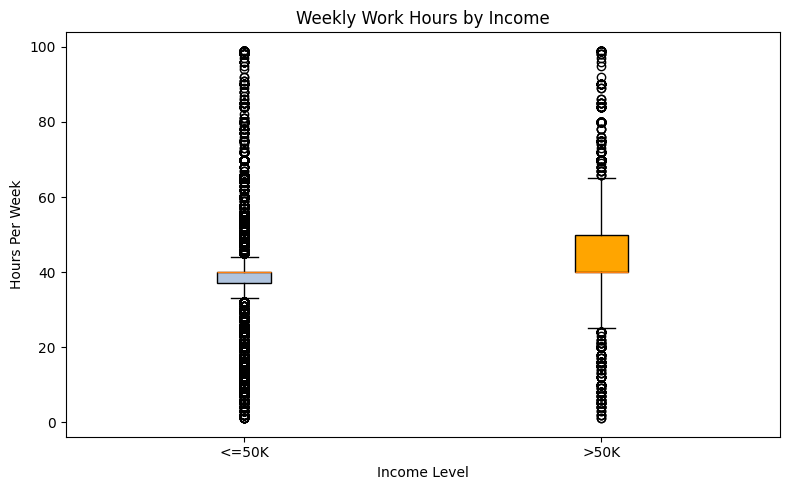

In [ ]:
## Weekly work hours and income

hour_groups = [
    df.loc[df["income"] == "<=50K", "hours-per-week"],
    df.loc[df["income"] == ">50K", "hours-per-week"]
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    hour_groups,
    tick_labels=["<=50K", ">50K"],
    patch_artist=True
)

box["boxes"][0].set_facecolor("lightsteelblue")
box["boxes"][1].set_facecolor("orange")

plt.title("Weekly Work Hours by Income")
plt.xlabel("Income Level")
plt.ylabel("Hours Per Week")
plt.tight_layout()

plt.savefig(
    "charts/04_hours_income.png",
    dpi=200
)
plt.show()

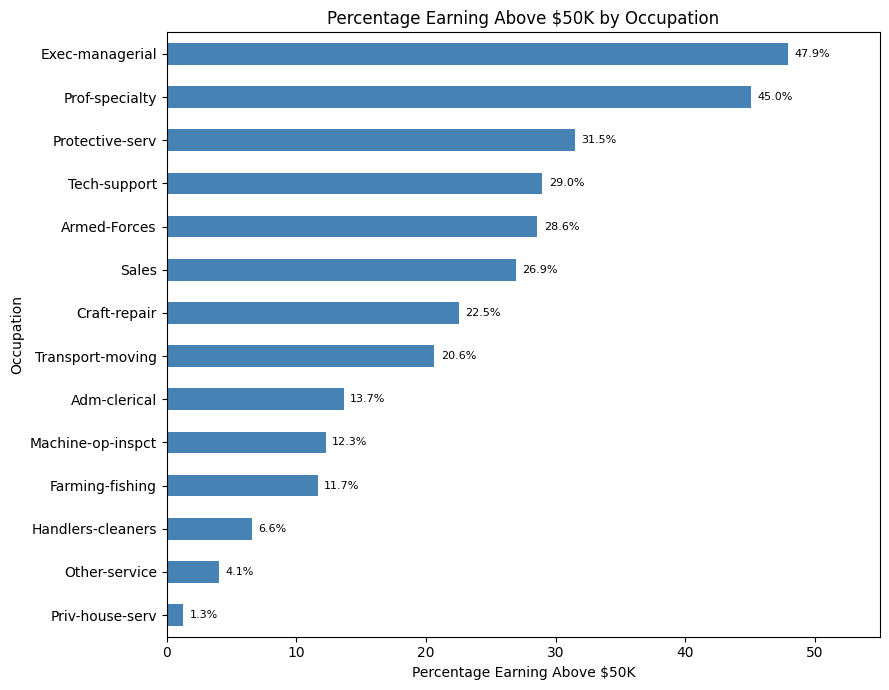

In [ ]:
## Occupation and income

occupation_income = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
) * 100

high_income_rate = (
    occupation_income[">50K"]
    .sort_values()
)

ax = high_income_rate.plot(
    kind="barh",
    color="steelblue",
    figsize=(9, 7)
)

plt.title("Percentage Earning Above $50K by Occupation")
plt.xlabel("Percentage Earning Above $50K")
plt.ylabel("Occupation")
plt.xlim(0, 55)

for position, value in enumerate(high_income_rate):
    ax.text(
        value + 0.5,
        position,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "charts/05_occupation_income.png",
    dpi=200
)
plt.show()

In [19]:
print("All five charts were saved in the charts folder.")

for chart in sorted(Path("charts").glob("*.png")):
    print(chart.name)

All five charts were saved in the charts folder.
01_income_distribution.png
02_education_income.png
03_age_income.png
04_hours_income.png
05_occupation_income.png
